In [ ]:
# 1. Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
# Visual configuration for plots
sns.set_theme(style="whitegrid")

In [ ]:
# 2. Loading the data
df = pd.read_csv('../WDI-2022-clustering/WDI2022_clusters.csv')

# Definition of the target column
target_col = 'life_expectancy_at_birth'

# Removing rows where our target variable is empty
df = df.dropna(subset=[target_col])

In [19]:
df.columns

Index(['Country Name', 'Country Code', 'Region',
       'corruption_perception_estimate', 'access_to_electricity_percent',
       'co2_emissions_per_capita',
       'mobile_cellular_subscriptions_per_100_people',
       'agriculture_value_added_percent_gdp',
       'industry_value_added_percent_gdp', 'gdp_growth_annual_percent',
       'gdp_per_capita_usd', 'stability_of_government_estimate',
       'health_expenditure_pct_gdp', 'child_mortality_rate',
       'life_expectancy_at_birth', 'fertility_rate_total',
       'population_65_plus_percent', 'population_total',
       'urban_population_percent', 'Cluster_KMeans', 'Cluster_HDBSCAN'],
      dtype='object')

In [ ]:
# 3. Separating the predictor variables (X) and the target variable (y)
cols_to_drop = ['Country Name', 'Country Code', 'Region', 'child_mortality_rate',  
                'Cluster_KMeans', 'Cluster_HDBSCAN', target_col] 
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df[target_col]

In [21]:
# 4. Splitting into Train (80%) and Test (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# 5. Training the Regression Model
print("Training the Random Forest Regressor model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

Training the Random Forest Regressor model...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
# 6. Making predictions on test data
y_pred = rf_model.predict(X_test)

In [24]:
# 7. Evaluating the Model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Evaluation Metrics ---")
print(f"R² (Explanatory power): {r2:.4f} (Closer to 1.0 is better)")
print(f"MAE (Mean Absolute Error): {mae:.2f} years")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} years")


--- Evaluation Metrics ---
R² (Explanatory power): 0.7127 (Closer to 1.0 is better)
MAE (Mean Absolute Error): 2.87 years
RMSE (Root Mean Squared Error): 4.08 years


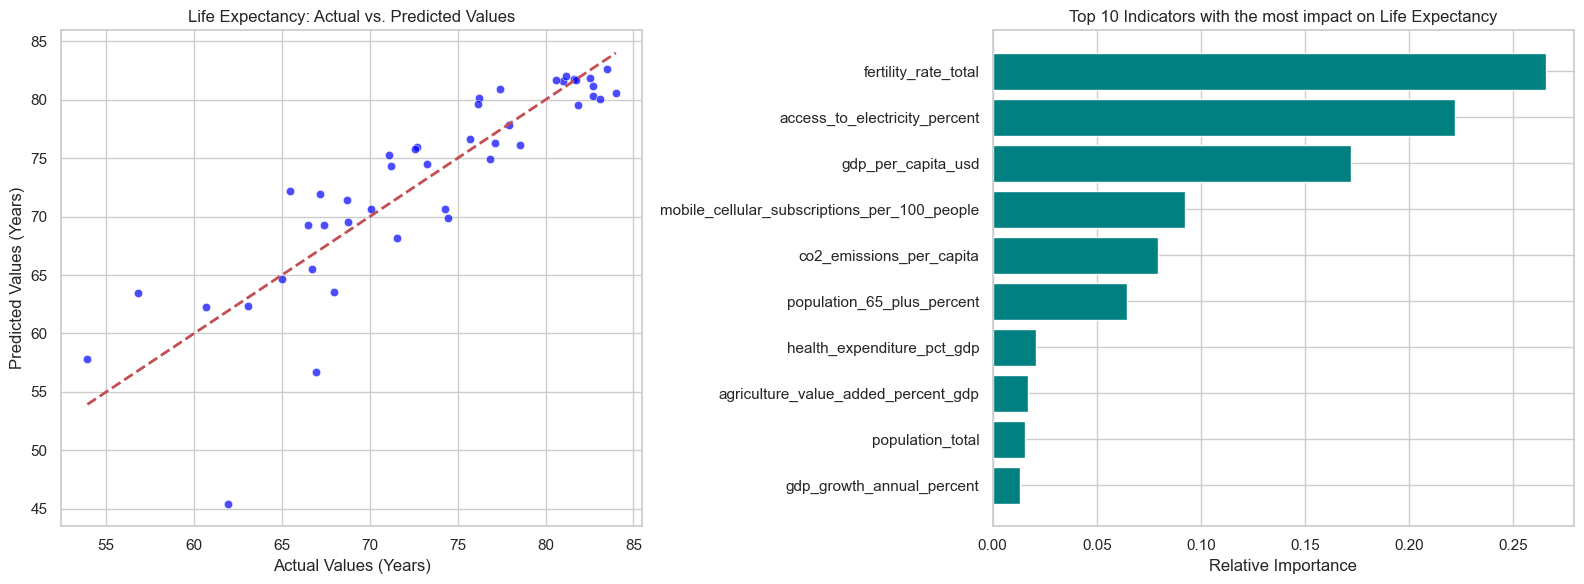

In [ ]:
# ==========================================
# SOME PLOTS TO VISUALIZE THE RESULTS
# ==========================================

plt.figure(figsize=(16, 6))

# Plot 1: Actual vs. Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='blue')
# Perfect reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Life Expectancy: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Years)')
plt.ylabel('Predicted Values (Years)')

# Plot 2: Feature Importance
plt.subplot(1, 2, 2)
importances = rf_model.feature_importances_
# Getting the top 10 most important indicators
indices = np.argsort(importances)[-10:] 
features = X.columns

plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Top 10 Indicators with the most impact on Life Expectancy')
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()